In [1]:
import numpy as np
import scipy.sparse as sp
import math
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import itertools
import torch.nn.functional as F
from numpy.polynomial.legendre import legval

# 5-point Generator

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

plt.rcParams["figure.figsize"] = (7, 5)

Device: cuda


In [3]:
@dataclass
class StructuredGrid2D:
    nx: int
    ny: int
    lx: float
    ly: float
    thickness: float

    def __post_init__(self):
        self.n_cells = self.nx * self.ny
        self.dx = self.lx / self.nx
        self.dy = self.ly / self.ny
        self.bulk_volume = self.dx * self.dy * self.thickness
        self.face_i, self.face_j, self.face_area, self.face_distance = self._build_connectivity()
        self.cell_centers = self._build_centers()

    def cell_index(self, i, j):
        return i + self.nx * j

    def _build_centers(self):
        centers = np.zeros((self.n_cells, 2))
        for j in range(self.ny):
            for i in range(self.nx):
                c = self.cell_index(i, j)
                centers[c, 0] = (i + 0.5) * self.dx
                centers[c, 1] = (j + 0.5) * self.dy
        return centers

    def _build_connectivity(self):
        fi, fj, area, dist = [], [], [], []
        for j in range(self.ny):
            for i in range(self.nx):
                c = self.cell_index(i, j)
                if i + 1 < self.nx:
                    fi.append(c)
                    fj.append(self.cell_index(i + 1, j))
                    area.append(self.dy * self.thickness)
                    dist.append(self.dx)
                if j + 1 < self.ny:
                    fi.append(c)
                    fj.append(self.cell_index(i, j + 1))
                    area.append(self.dx * self.thickness)
                    dist.append(self.dy)
        return np.array(fi), np.array(fj), np.array(area, float), np.array(dist, float)

    def reshape(self, field):
        return np.asarray(field).reshape(self.ny, self.nx)


In [4]:
@dataclass
class CoreyFluid:
    mu_w: float = 1e-3
    mu_o: float = 4e-3
    s_wr: float = 0.20
    s_or: float = 0.25
    krw0: float = 0.30
    kro0: float = 1.00
    n_w: float = 2.0
    n_o: float = 2.0

    @property
    def s_min(self):
        return self.s_wr

    @property
    def s_max(self):
        return 1.0 - self.s_or

    def effective_saturation(self, sw):
        swe = (sw - self.s_wr) / (1.0 - self.s_wr - self.s_or)
        return np.clip(swe, 0.0, 1.0)

    def mobilities(self, sw):
        swe = self.effective_saturation(sw)
        krw = self.krw0 * swe ** self.n_w
        kro = self.kro0 * (1.0 - swe) ** self.n_o
        lam_w = krw / self.mu_w
        lam_o = kro / self.mu_o
        lam_t = lam_w + lam_o
        fw = lam_w / (lam_t + 1e-30)
        return lam_w, lam_o, lam_t, fw


class IMPES2D:
    def __init__(self, grid, phi=0.01, perm_mD=1.0):
        self.grid = grid
        self.phi = phi
        self.perm = perm_mD * 9.869233e-16
        self.fi = grid.face_i
        self.fj = grid.face_j
        self.T_geom = self.perm * grid.face_area / grid.face_distance

        self.rows_pattern = np.concatenate([self.fi, self.fj, np.arange(grid.n_cells)])
        self.cols_pattern = np.concatenate([self.fj, self.fi, np.arange(grid.n_cells)])

        self.inj = grid.cell_index(0, 0)
        self.prod = grid.cell_index(grid.nx - 1, grid.ny - 1)

        year = 365.0 * 24.0 * 3600.0
        pore_volume = phi * grid.lx * grid.ly * grid.thickness
        self.q_inj = 0.1 * pore_volume / year

        self.q_total = np.zeros(grid.n_cells)
        self.q_total[self.inj] = self.q_inj
        self.q_total[self.prod] = -self.q_inj
        self.gauge_cell = self.prod

    def pressure_solve(self, sw, fluid):
        _, _, lam_t, fw = fluid.mobilities(sw)
        lt_i = lam_t[self.fi]
        lt_j = lam_t[self.fj]
        lt_face = 2.0 * lt_i * lt_j / (lt_i + lt_j + 1e-30)
        T_face = self.T_geom * lt_face

        diag = np.zeros(self.grid.n_cells)
        np.add.at(diag, self.fi, T_face)
        np.add.at(diag, self.fj, T_face)

        data = np.concatenate([-T_face, -T_face, diag])
        A = sp.csr_matrix((data, (self.rows_pattern, self.cols_pattern)), shape=(self.grid.n_cells, self.grid.n_cells)).tolil()
        b = self.q_total.copy()

        # Gauge condition for no-flow pressure equation
        A[self.gauge_cell, :] = 0.0
        A[self.gauge_cell, self.gauge_cell] = 1.0
        b[self.gauge_cell] = 0.0

        p = spla.spsolve(A.tocsc(), b)
        F_total = -T_face * (p[self.fj] - p[self.fi])
        return p, F_total, fw

    def cfl_dt(self, F_total, cfl=0.5):
        outflux = np.zeros(self.grid.n_cells)
        np.add.at(outflux, self.fi, np.maximum(F_total, 0.0))
        np.add.at(outflux, self.fj, np.maximum(-F_total, 0.0))
        outflux += np.maximum(-self.q_total, 0.0)
        pv = self.phi * self.grid.bulk_volume
        return float(np.min(cfl * pv / np.maximum(outflux, 1e-30)))

    def transport_step(self, sw, F_total, fw, fluid, dt):
        upwind = np.where(F_total >= 0.0, self.fi, self.fj)
        Fw = fw[upwind] * F_total

        div = np.zeros(self.grid.n_cells)
        np.add.at(div, self.fi, Fw)
        np.add.at(div, self.fj, -Fw)

        q_w = np.zeros(self.grid.n_cells)
        q_w[self.inj] = self.q_inj
        q_w[self.prod] = fw[self.prod] * (-self.q_inj)

        pv = self.phi * self.grid.bulk_volume
        sw_new = sw + dt / pv * (q_w - div)
        return np.clip(sw_new, fluid.s_min, fluid.s_max)

    def run(self, n_w=2.0, n_o=2.0, final_years=20.0, n_save=41, cfl=0.5, max_dt_days=30.0):
        year = 365.0 * 24.0 * 3600.0
        final_time = final_years * year
        save_times = np.linspace(0.0, final_time, n_save)

        fluid = CoreyFluid(n_w=n_w, n_o=n_o)
        sw = np.full(self.grid.n_cells, fluid.s_min)

        saved_t, saved_sw, saved_p = [], [], []

        t = 0.0
        next_save = 0

        while next_save < len(save_times):
            target = save_times[next_save]
            while t < target - 1e-9:
                p, F, fw = self.pressure_solve(sw, fluid)
                dt = self.cfl_dt(F, cfl=cfl)
                dt = min(dt, max_dt_days * 86400.0, target - t)
                sw = self.transport_step(sw, F, fw, fluid, dt)
                t += dt

            p, F, fw = self.pressure_solve(sw, fluid)
            saved_t.append(t)
            saved_sw.append(sw.copy())
            saved_p.append(p.copy())
            next_save += 1

        return {
            "times": np.asarray(saved_t),
            "saturation": np.asarray(saved_sw),
            "pressure": np.asarray(saved_p),
            "n_w": n_w,
            "n_o": n_o,
        }

In [5]:
grid = StructuredGrid2D(nx=30, ny=30, lx=500.0, ly=500.0, thickness=50.0)
sim = IMPES2D(grid, phi=0.01, perm_mD=1.0)

param_train = [
    (2.0, 2.0),
    (2.0, 3.0),
    (3.0, 2.0),
    (3.0, 3.0),
    (4.0, 2.5),
    (2.5, 4.0),
]

solutions = []
for nw, no in param_train:
    print(f"Generating FV solution for n_w={nw}, n_o={no}")
    solutions.append(sim.run(n_w=nw, n_o=no, final_years=20.0, n_save=41))

print("Data generation finished.")

Generating FV solution for n_w=2.0, n_o=2.0
Generating FV solution for n_w=2.0, n_o=3.0
Generating FV solution for n_w=3.0, n_o=2.0
Generating FV solution for n_w=3.0, n_o=3.0
Generating FV solution for n_w=4.0, n_o=2.5
Generating FV solution for n_w=2.5, n_o=4.0
Data generation finished.


In [6]:
def build_dataset(solutions, grid, max_points_per_solution=25000):
    X_list, Y_list = [], []
    centers = grid.cell_centers
    x = centers[:, 0] / grid.lx
    y = centers[:, 1] / grid.ly
    T_final = 20.0 * 365.0 * 24.0 * 3600.0

    global_p_scale = max(max(np.max(np.abs(sol["pressure"])) for sol in solutions), 1.0)

    for sol in solutions:
        times = sol["times"]
        Sw = sol["saturation"]
        P = sol["pressure"] / global_p_scale

        X_sol, Y_sol = [], []
        for it, t in enumerate(times):
            nc = grid.n_cells
            X = np.stack([
                x,
                y,
                np.full(nc, t / T_final),
                np.full(nc, sol["n_w"]),
                np.full(nc, sol["n_o"]),
            ], axis=1)
            Y = np.stack([Sw[it], P[it]], axis=1)
            X_sol.append(X)
            Y_sol.append(Y)

        X_sol = np.vstack(X_sol)
        Y_sol = np.vstack(Y_sol)

        if len(X_sol) > max_points_per_solution:
            idx = np.random.choice(len(X_sol), max_points_per_solution, replace=False)
            X_sol = X_sol[idx]
            Y_sol = Y_sol[idx]

        X_list.append(X_sol)
        Y_list.append(Y_sol)

    X = np.vstack(X_list).astype(np.float32)
    Y = np.vstack(Y_list).astype(np.float32)

    return X, Y, global_p_scale

X, Y, pressure_scale = build_dataset(solutions, grid)
print("Dataset:", X.shape, Y.shape)
print("Pressure scale:", pressure_scale)

Dataset: (150000, 5) (150000, 2)
Pressure scale: 347715328.58612746


# Net part

In [20]:
# Normalize parameter inputs n_w,n_o to [0,1]
nw_min, nw_max = 2.0, 4.0
no_min, no_max = 2.0, 4.0

Xn = X.copy()
Xn[:, 3] = (Xn[:, 3] - nw_min) / (nw_max - nw_min)
Xn[:, 4] = (Xn[:, 4] - no_min) / (no_max - no_min)

dataset = TensorDataset(torch.tensor(Xn), torch.tensor(Y))
loader = DataLoader(dataset, batch_size=8192, shuffle=True)



class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [nn.Linear(5, 128), nn.Tanh()]
        for _ in range(5 - 1):
            layers += [nn.Linear(128, 128), nn.Tanh()]
        layers.append(nn.Linear(128, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        raw = self.net(x)

        # Sw in 0.20 - 0.75
        sw = 0.20 + (0.75 - 0.20) * torch.sigmoid(raw[:, 0:1])

        # normalized pressure
        p = raw[:, 1:2]
        return torch.cat([sw, p], dim=1)

model_net = MLP().to(device)
optimizer = torch.optim.Adam(model_net.parameters(), lr=1e-3)
mse = nn.MSELoss()


In [21]:

def initial_condition_loss(model, batch_size):
    x = torch.rand(batch_size, 1, device=device)
    y = torch.rand(batch_size, 1, device=device)
    t = torch.zeros(batch_size, 1, device=device)
    nw = torch.rand(batch_size, 1, device=device)
    no = torch.rand(batch_size, 1, device=device)
    inp = torch.cat([x, y, t, nw, no], dim=1)
    sw = model(inp)[:, 0:1]
    return torch.mean((sw - 0.20) ** 2)

def smoothness_loss(model, batch_size):
    inp = torch.rand(batch_size, 5, device=device)
    inp.requires_grad_(True)
    sw = model(inp)[:, 0:1]
    grad = torch.autograd.grad(
        sw, inp,
        grad_outputs=torch.ones_like(sw),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.mean(grad[:, 0:2] ** 2)

In [22]:
def corey_relperm_torch(Sw, nw, no, Swr=0.20, Sor=0.25, krw0=0.30, kro0=1.00):
    Se = (Sw - Swr) / (1.0 - Swr - Sor)
    Se = torch.clamp(Se, 0.0, 1.0)

    krw = krw0 * Se ** nw
    kro = kro0 * (1.0 - Se) ** no

    return krw, kro


def pde_residual_loss(
    model,
    batch_size,
    phi,
    perm_mD,
    mu_w,
    mu_o,
    Lx,
    Ly,
    T_final,
    device):
    x = torch.rand(batch_size, 1, device=device, requires_grad=True)
    y = torch.rand(batch_size, 1, device=device, requires_grad=True)
    t = torch.rand(batch_size, 1, device=device, requires_grad=True)
    nw_norm = torch.rand(batch_size, 1, device=device)
    no_norm = torch.rand(batch_size, 1, device=device)
    nw = 2.0 + 2.0 * nw_norm
    no = 2.0 + 2.0 * no_norm
    inp = torch.cat([x, y, t, nw_norm, no_norm], dim=1)

    pred = model(inp)
    Sw = torch.clamp(pred[:, 0:1], 0.20, 1.0 - 0.25)
    p = pred[:, 1:2] * 1
    krw, kro = corey_relperm_torch(Sw, nw, no)

    lambda_w = krw / mu_w
    lambda_o = kro / mu_o
    lambda_t = lambda_w + lambda_o
    K = perm_mD * 9.869233e-16 # from mD to m^2

    p_x = torch.autograd.grad(p, x,
        grad_outputs=torch.ones_like(p),
        create_graph=True,
        retain_graph=True)[0]
    p_y = torch.autograd.grad(p, y,
        grad_outputs=torch.ones_like(p),
        create_graph=True,
        retain_graph=True)[0]
    p_X = p_x / Lx # chain rule
    p_Y = p_y / Ly

    flux_p_x = K * lambda_t * p_X # pressure equation
    flux_p_y = K * lambda_t * p_Y

    d_flux_p_x_dx = torch.autograd.grad(
        flux_p_x, x,
        grad_outputs=torch.ones_like(flux_p_x),
        create_graph=True,
        retain_graph=True)[0] / Lx
    d_flux_p_y_dy = torch.autograd.grad(
        flux_p_y, y,
        grad_outputs=torch.ones_like(flux_p_y),
        create_graph=True,
        retain_graph=True
    )[0] / Ly
    pressure_residual = d_flux_p_x_dx + d_flux_p_y_dy

    # saturation equation
    Sw_t = torch.autograd.grad(Sw, t,
        grad_outputs=torch.ones_like(Sw),
        create_graph=True,
        retain_graph=True)[0]
    Sw_T = Sw_t / T_final # chain rule

    flux_w_x = K * lambda_w * p_X
    flux_w_y = K * lambda_w * p_Y

    d_flux_w_x_dx = torch.autograd.grad(
        flux_w_x, x,
        grad_outputs=torch.ones_like(flux_w_x),
        create_graph=True,
        retain_graph=True)[0] / Lx

    d_flux_w_y_dy = torch.autograd.grad(
        flux_w_y, y,
        grad_outputs=torch.ones_like(flux_w_y),
        create_graph=True,
        retain_graph=True)[0] / Ly

    water_flux_div = d_flux_w_x_dx + d_flux_w_y_dy
    saturation_residual = phi * Sw_T - water_flux_div
    loss_pressure = torch.mean(pressure_residual ** 2)
    loss_saturation = torch.mean(saturation_residual ** 2)

    return loss_pressure + loss_saturation

In [ ]:
from tqdm.auto import tqdm
n_epochs = 250 # loss for 250 epochs - 8.39e-5, for 200 epochs - 7.87e-5. So model was a bit overlearned for 250.
loss_history = []

epoch_bar = tqdm(range(n_epochs), desc="train...", unit="epoch")

for epoch in range(1, n_epochs + 1):
    total = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model_net(xb)
        loss_sw = mse(pred[:, 0:1], yb[:, 0:1])
        loss_p = mse(pred[:, 1:2], yb[:, 1:2])
        loss_ic = initial_condition_loss(model_net, 1024)
        loss_sm = smoothness_loss(model_net, 512)
        loss_pde = pde_residual_loss(model_net, batch_size=512, phi=0.01, perm_mD=1.0, mu_w=1e-3,
                                     mu_o=4e-3, Lx=500.0, Ly=500.0,
                                     T_final=20.0 * 365.25 * 24.0 * 3600.0,
                                     device=device)
        loss = loss_sw + 0.1 * loss_p + 2.0 * loss_ic + 0.001 * loss_sm + 0.001 * loss_pde

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item() * len(xb)
    avg = total / len(dataset)
    loss_history.append(avg)

    epoch_bar.set_postfix(loss=avg)
    if epoch % 10 == 0:
        print('epoch= ', epoch, 'loss= ', avg)


train...:   0%|          | 0/250 [00:00<?, ?epoch/s]

epoch=  10 loss=  0.006490468263675769
epoch=  20 loss=  0.0027047005004932484
epoch=  30 loss=  0.002071157944401105
epoch=  40 loss=  0.0011597546949610115
epoch=  50 loss=  0.0007879926817429562
epoch=  60 loss=  0.0007097646314216157
epoch=  70 loss=  0.0006450273369563123
epoch=  80 loss=  0.0005383378259713451
epoch=  90 loss=  0.0006463188653004666
epoch=  100 loss=  0.0004941031034663319
epoch=  110 loss=  0.0004713231019861996
epoch=  120 loss=  0.00045097850654274226
epoch=  130 loss=  0.00040200077883278333
epoch=  140 loss=  0.0003669699693284929
epoch=  150 loss=  0.00037663361915076773
epoch=  160 loss=  0.00035234194718146075
epoch=  170 loss=  0.0003437377616794159
epoch=  180 loss=  0.0003264025228656828
epoch=  190 loss=  0.00032431091772392394
epoch=  200 loss=  0.00030858727987234793
epoch=  210 loss=  0.000309361362401396
epoch=  220 loss=  0.00030917644361034034
epoch=  230 loss=  0.00036089480405673385
epoch=  240 loss=  0.00028195370614839094
epoch=  250 loss=  

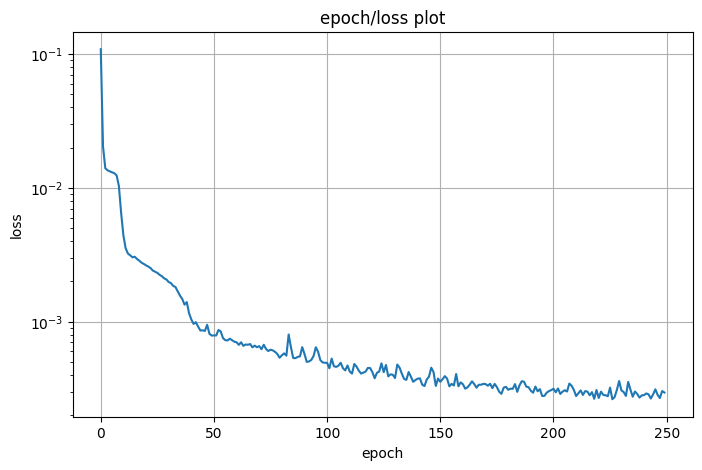

In [24]:
plt.figure(figsize=(8, 5))
# plt.plot(range(n_epochs), loss_history)
plt.semilogy(loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('epoch/loss plot')
plt.grid(True)
plt.show()

# Sobol coefficient

In [25]:
!pip install SALib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 44.3 MB/s eta 0:00:00


In [26]:
from SALib.sample import saltelli
from SALib.analyze import sobol

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/tmp/ipykernel_463/1394346549.py:12: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


sobol coeffs for Y_sw:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.003650  0.004234  0.005148  0.000893
4      x4  0.021781  0.040877  0.017030  0.006188
0      x0  0.074330  0.173528  0.033010  0.040002
1      x1  0.066353  0.182744  0.041761  0.042827
2      x2  0.669542  0.854038  0.117100  0.094434


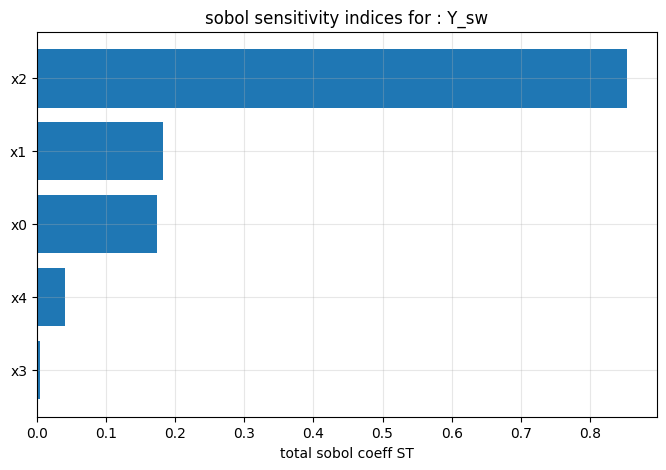

pairwise interactions S2 for  Y_sw
    x0        x1        x2        x3        x4
x0 NaN  0.014062  0.056579 -0.013893 -0.014380
x1 NaN       NaN  0.063924 -0.025029 -0.024033
x2 NaN       NaN       NaN  0.057548  0.066707
x3 NaN       NaN       NaN       NaN -0.004325
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------




sobol coeffs for Y_p:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.050997  0.091345  0.026984  0.013170
0      x0  0.098719  0.113271  0.027070  0.014880
1      x1  0.101231  0.115547  0.026334  0.017216
4      x4  0.209860  0.257151  0.045554  0.026218
2      x2  0.418510  0.519432  0.066789  0.047102


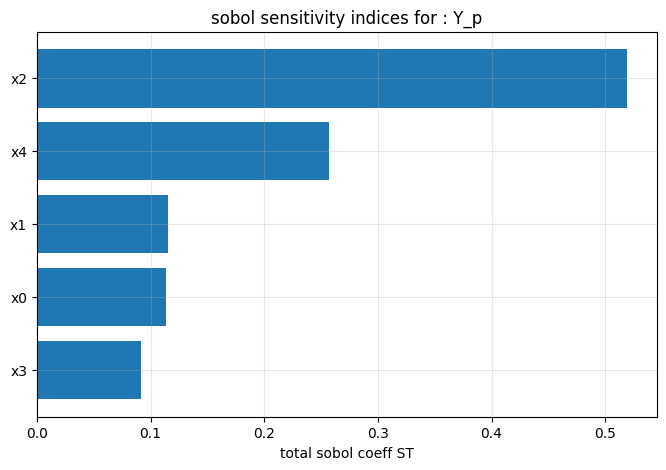

pairwise interactions S2 for  Y_p
    x0        x1        x2        x3        x4
x0 NaN  0.010205 -0.002054 -0.004368 -0.009196
x1 NaN       NaN  0.000697 -0.001864 -0.000406
x2 NaN       NaN       NaN  0.046761  0.060037
x3 NaN       NaN       NaN       NaN -0.012704
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------






In [27]:
X_data = torch.cat([xb for xb, yb in loader], dim=0)#.detach().cpu().numpy()
features = ['x'+str(i) for i in range(X_data.shape[1])]

problem = {
    'num_vars': X_data.shape[1],
    'names': features,
    'bounds': [
        [X_data[:, i].min(), X_data[:, i].max()]
        for i in range(X_data.shape[1])]
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)
X_sobol = torch.tensor(param_values, dtype=torch.float32).to(device)

model_net.eval()
with torch.no_grad():
    Y_pred = model_net(X_sobol).detach().cpu().numpy()

Y_sw = Y_pred[:, 0]
Y_p = Y_pred[:, 1]

for y_tpl in ((Y_sw, 'Y_sw'), (Y_p, 'Y_p')):
    Si = sobol.analyze(problem, y_tpl[0], calc_second_order=True)
    sobol_df = pd.DataFrame({
        'feature': problem['names'],
        'S1': Si['S1'],
        'ST': Si['ST'],
        'S1_conf': Si['S1_conf'],
        'ST_conf': Si['ST_conf']})
    sobol_df_sorted = sobol_df.sort_values('ST')
    print(f'sobol coeffs for {y_tpl[1]}:')
    print(sobol_df.sort_values('ST'))

    plt.figure(figsize=(8, 5))
    plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
    plt.xlabel('total sobol coeff ST')
    plt.title(f'sobol sensitivity indices for : {y_tpl[1]}')
    plt.grid(True, alpha=0.3)
    plt.show()

    print('pairwise interactions S2 for ', y_tpl[1])
    print(pd.DataFrame(
        Si['S2'],
        index=problem['names'],
        columns=problem['names']
    ))
    print('\n----------------------------------------\n\n\n\n')

In [28]:
Si

{'S1': array([0.09871898, 0.10123061, 0.41850972, 0.05099743, 0.20986015]),
 'S1_conf': array([0.02706998, 0.02633439, 0.06678874, 0.02698365, 0.04555414]),
 'ST': array([0.11327113, 0.11554719, 0.51943169, 0.09134537, 0.25715093]),
 'ST_conf': array([0.01488004, 0.01721619, 0.04710175, 0.01317045, 0.02621838]),
 'S2': array([[        nan,  0.010205  , -0.00205438, -0.00436789, -0.00919567],
        [        nan,         nan,  0.00069663, -0.0018639 , -0.00040556],
        [        nan,         nan,         nan,  0.04676123,  0.06003694],
        [        nan,         nan,         nan,         nan, -0.012704  ],
        [        nan,         nan,         nan,         nan,         nan]]),
 'S2_conf': array([[       nan, 0.04295576, 0.04403613, 0.04248536, 0.04634561],
        [       nan,        nan, 0.04717107, 0.04409613, 0.03950447],
        [       nan,        nan,        nan, 0.0887897 , 0.09495115],
        [       nan,        nan,        nan,        nan, 0.03978177],
        [   

# Linear regression + Random Forest

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns

In [30]:
X

array([[0.38333333, 0.81666666, 0.425     , 2.        , 2.        ],
       [0.28333333, 0.6166667 , 0.625     , 2.        , 2.        ],
       [0.28333333, 0.95      , 0.775     , 2.        , 2.        ],
       ...,
       [0.21666667, 0.08333334, 0.6       , 2.5       , 4.        ],
       [0.08333334, 0.5833333 , 0.125     , 2.5       , 4.        ],
       [0.15      , 0.08333334, 0.425     , 2.5       , 4.        ]],
      dtype=float32)

In [31]:
Y

array([[0.6543987 , 0.24839787],
       [0.7050217 , 0.24191993],
       [0.64872295, 0.21714629],
       ...,
       [0.6632151 , 0.56438696],
       [0.54784614, 0.30075938],
       [0.6675977 , 0.63935393]], dtype=float32)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)


print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)

# RandomForestRegressor
print('RandomForestRegressor')

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    n_estimators=100,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None,
    max_depth=10,
    bootstrap=True
)

# param_dist = {
#     'n_estimators': [100, 300, 500, 800],
#     'max_depth': [None, 5, 10, 15, 20, 30],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 2, 4, 8],
#     'max_features': [1, 2, 3, 'sqrt', None],
#     'bootstrap': [True, False],
# }
# search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=2,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )
# search.fit(X_train, y_train)
rf.fit(X_train, y_train)

# print('best params:', search.best_params_)
# best params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None, 'bootstrap': True}
# best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
# print('best CV score:', -search.best_score_)

random_forest_model = rf # search.best_estimator_


random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('random forest results:')
print('MAE: ', mean_absolute_error(y_test, y_pred_rf))
print('MSE: ',mean_squared_error(y_test, y_pred_rf))
print('RMSE: ', np.sqrt(mse_rf))
print('R^2: ', r2_score(y_test, y_pred_rf))

linear reg results:
linear model coeffs:  [[-0.1172305  -0.11837891  0.3115485   0.0071483  -0.038144  ]
 [-0.13139324 -0.1321565   0.00153746  0.03757302  0.08978384]]
MAE:  0.06889481097459793
MSE:  0.008739719167351723
RMSE:  0.09348646515593433
R^2:  0.5195515155792236
RandomForestRegressor
random forest results:
MAE:  0.01083469728648858
MSE:  0.0003430811535391657
RMSE:  0.01852244998749263
R^2:  0.9790098834397254


## Sobol index

/tmp/ipykernel_463/2972478617.py:12: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


sobol coeffs for Y_sw:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.000000  0.000000  0.000000  0.000000
4      x4  0.000000  0.000000  0.000000  0.000000
0      x0  0.065930  0.182154  0.035354  0.041476
1      x1  0.072245  0.206157  0.044794  0.049340
2      x2  0.672717  0.868870  0.095396  0.079990


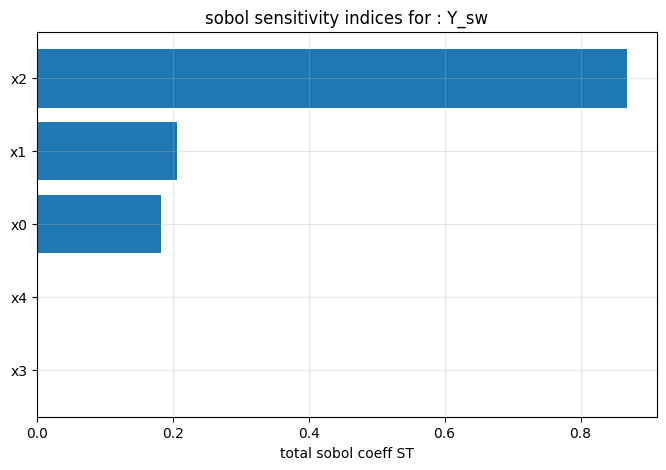

pairwise interactions S2 for  Y_sw
    x0        x1        x2        x3        x4
x0 NaN  0.023808  0.081921 -0.003760 -0.003760
x1 NaN       NaN  0.065167 -0.014160 -0.014160
x2 NaN       NaN       NaN  0.047066  0.047066
x3 NaN       NaN       NaN       NaN  0.000000
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------




sobol coeffs for Y_p:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.000000  0.000000  0.000000  0.000000
4      x4  0.000000  0.000000  0.000000  0.000000
0      x0  0.265293  0.329543  0.047044  0.033844
1      x1  0.276303  0.345291  0.051687  0.038655
2      x2  0.393642  0.417660  0.059361  0.044902


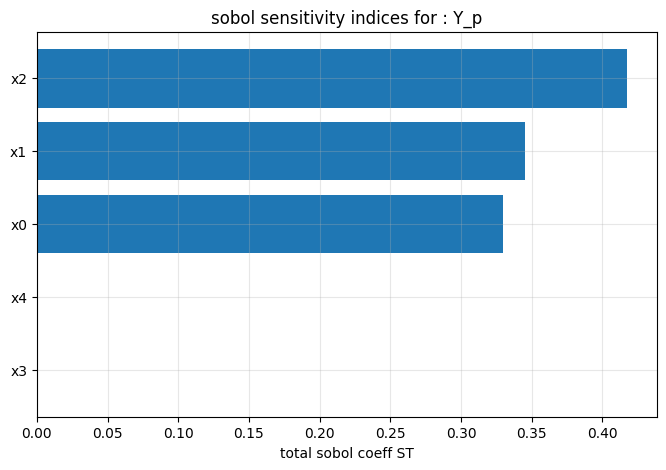

pairwise interactions S2 for  Y_p
    x0        x1        x2        x3        x4
x0 NaN  0.049909  0.009904 -0.008867 -0.008867
x1 NaN       NaN  0.013189 -0.002130 -0.002130
x2 NaN       NaN       NaN -0.001072 -0.001072
x3 NaN       NaN       NaN       NaN  0.000000
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------






In [33]:
X_data = torch.cat([xb for xb, yb in loader], dim=0)#.detach().cpu().numpy()
features = ['x'+str(i) for i in range(X_data.shape[1])]

problem = {
    'num_vars': X_data.shape[1],
    'names': features,
    'bounds': [
        [X_data[:, i].min(), X_data[:, i].max()]
        for i in range(X_data.shape[1])]
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)
X_sobol = torch.tensor(param_values, dtype=torch.float32).to(device)

# random_forest_model.eval()
# with torch.no_grad():
Y_pred = random_forest_model.predict(X_sobol.cpu())#.detach().cpu().numpy()

Y_sw = Y_pred[:, 0]
Y_p = Y_pred[:, 1]

for y_tpl in ((Y_sw, 'Y_sw'), (Y_p, 'Y_p')):
    Si = sobol.analyze(problem, y_tpl[0], calc_second_order=True)
    sobol_df = pd.DataFrame({
        'feature': problem['names'],
        'S1': Si['S1'],
        'ST': Si['ST'],
        'S1_conf': Si['S1_conf'],
        'ST_conf': Si['ST_conf']})
    sobol_df_sorted = sobol_df.sort_values('ST')
    print(f'sobol coeffs for {y_tpl[1]}:')
    print(sobol_df.sort_values('ST'))

    plt.figure(figsize=(8, 5))
    plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
    plt.xlabel('total sobol coeff ST')
    plt.title(f'sobol sensitivity indices for : {y_tpl[1]}')
    plt.grid(True, alpha=0.3)
    plt.show()

    print('pairwise interactions S2 for ', y_tpl[1])
    print(pd.DataFrame(
        Si['S2'],
        index=problem['names'],
        columns=problem['names']
    ))
    print('\n----------------------------------------\n\n\n\n')

# anova decomposition

In [34]:
X[:, 4].max()

np.float32(4.0)

In [35]:
d=5
N_train = 20000
N_val = 100000

X_train = torch.stack([
    torch.rand(N_train) * (0.98333335 - 0.016666668) + 0.016666668,
    torch.rand(N_train) * (0.98333335 - 0.016666668) + 0.016666668,
    torch.rand(N_train) * (1 - 0) + 0,
    torch.rand(N_train) * (4 - 2) + 2,
    torch.rand(N_train) * (4 - 2) + 2], dim=1).to(device)

model_net = model_net.to(device)
model_net.eval()

with torch.no_grad():
    y_train = model_net(X_train)[:,1]
    print(y_train.shape)


X_val = torch.stack([
    torch.rand(N_val) * (0.98333335 - 0.016666668) + 0.016666668,
    torch.rand(N_val) * (0.98333335 - 0.016666668) + 0.016666668,
    torch.rand(N_val) * (1 - 0) + 0,
    torch.rand(N_val) * (4 - 2) + 2,
    torch.rand(N_val) * (4 - 2) + 2], dim=1).to(device)

with torch.no_grad():
    y_val = model_net(X_val)[:,1]
    print(y_val.shape)

print('train:', X_train.shape, y_train.shape)
print('val:', X_val.shape, y_val.shape)
print('f mean, validation:', y_val.mean())
print('f variance, validation:', y_val.var())

torch.Size([20000])
torch.Size([100000])
train: torch.Size([20000, 5]) torch.Size([20000])
val: torch.Size([100000, 5]) torch.Size([100000])
f mean, validation: tensor(0.6792, device='cuda:0')
f variance, validation: tensor(0.0473, device='cuda:0')


In [36]:

def all_subsets(d):
    subsets = [()]
    for r in range(1, d + 1):
        for s in itertools.combinations(range(d), r):
            subsets.append(s)
    return subsets


subsets = all_subsets(d)
subset_names = ['0' if len(s) == 0 else ''.join(str(i+1) for i in s) for s in subsets]
list(zip(subset_names, subsets))

[('0', ()),
 ('1', (0,)),
 ('2', (1,)),
 ('3', (2,)),
 ('4', (3,)),
 ('5', (4,)),
 ('12', (0, 1)),
 ('13', (0, 2)),
 ('14', (0, 3)),
 ('15', (0, 4)),
 ('23', (1, 2)),
 ('24', (1, 3)),
 ('25', (1, 4)),
 ('34', (2, 3)),
 ('35', (2, 4)),
 ('45', (3, 4)),
 ('123', (0, 1, 2)),
 ('124', (0, 1, 3)),
 ('125', (0, 1, 4)),
 ('134', (0, 2, 3)),
 ('135', (0, 2, 4)),
 ('145', (0, 3, 4)),
 ('234', (1, 2, 3)),
 ('235', (1, 2, 4)),
 ('245', (1, 3, 4)),
 ('345', (2, 3, 4)),
 ('1234', (0, 1, 2, 3)),
 ('1235', (0, 1, 2, 4)),
 ('1245', (0, 1, 3, 4)),
 ('1345', (0, 2, 3, 4)),
 ('2345', (1, 2, 3, 4)),
 ('12345', (0, 1, 2, 3, 4))]

In [37]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, depth):
        super().__init__()
        layers = []
        last = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(last, hidden))
            layers.append(nn.Tanh())
            last = hidden
        layers.append(nn.Linear(last, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class NeuralANOVA(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.d = d
        self.subsets = all_subsets(d)
        self.subset_names = ['0' if len(s) == 0 else ''.join(str(i+1) for i in s) for s in self.subsets]

        self.f0 = nn.Parameter(torch.zeros(1))

        self.nets = nn.ModuleDict()
        for name, subset in zip(self.subset_names, self.subsets):
            if len(subset) > 0:
                self.nets[name] = MLP(len(subset), hidden=hidden, depth=depth)

    def forward_terms(self, x):
        B = x.shape[0]
        terms = []

        for name, subset in zip(self.subset_names, self.subsets):
            if len(subset) == 0:
                terms.append(self.f0.expand(B, 1))
            else:
                xu = x[:, list(subset)]
                terms.append(self.nets[name](xu))

        return torch.cat(terms, dim=1)

    def forward(self, x):
        terms = self.forward_terms(x)
        return terms.sum(dim=1)


model = NeuralANOVA(d=d, hidden=64, depth=3).to(device)
sum(p.numel() for p in model.parameters())


267040

In [38]:

def centering_penalty(model, batch_size, n_mc):
    penalties = []

    for name, subset in zip(model.subset_names, model.subsets):
        if len(subset) == 0:
            continue

        subset = list(subset)
        m = len(subset)

        base = torch.empty(batch_size, m, device=device).uniform_(-1.0, 1.0)

        for local_j in range(m):
            vals = []
            for _ in range(n_mc):
                xu = base.clone()
                xu[:, local_j] = torch.empty(batch_size, device=device).uniform_(-1.0, 1.0)
                vals.append(model.nets[name](xu))
            mean_over_j = torch.stack(vals, dim=0).mean(dim=0)
            penalties.append(torch.mean(mean_over_j**2))

    return torch.stack(penalties).mean()

In [39]:
batch_size = 1024

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=batch_size,
    shuffle=True)

val_x_t = torch.tensor(X_val, device=device)
val_y_t = torch.tensor(y_val, device=device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)

lambda_center = 1.0

history = []

n_epochs = 150

for epoch in range(1, n_epochs + 1):
    model.train()
    total_loss_acc = 0.0
    rec_loss_acc = 0.0
    center_loss_acc = 0.0
    n_seen = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)
        rec_loss = F.mse_loss(pred, yb)

        center_loss = centering_penalty(model, batch_size=128, n_mc=8)

        loss = rec_loss + lambda_center * center_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss_acc += loss.item() * xb.size(0)
        rec_loss_acc += rec_loss.item() * xb.size(0)
        center_loss_acc += center_loss.item() * xb.size(0)
        n_seen += xb.size(0)

    scheduler.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(val_x_t)
        val_mse = F.mse_loss(val_pred, val_y_t).item()
        val_rmse = math.sqrt(val_mse)
        val_rel_rmse = val_rmse / float(torch.std(val_y_t).cpu())

    row = {
        'epoch': epoch,
        'train_total_loss': total_loss_acc / n_seen,
        'train_rec_loss': rec_loss_acc / n_seen,
        'train_center_loss': center_loss_acc / n_seen,
        'val_mse': val_mse,
        'val_rmse': val_rmse,
        'val_rel_rmse': val_rel_rmse,
        'lr': scheduler.get_last_lr()[0]
    }
    history.append(row)

    print(
        f'Epoch {epoch} | '
        f'rec={row['train_rec_loss']} | '
        f'center={row['train_center_loss']} | '
        f'val_RMSE={val_rmse} | '
        f'rel={val_rel_rmse}')

history = pd.DataFrame(history)
history.tail()


/tmp/ipykernel_463/186990816.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
/tmp/ipykernel_463/186990816.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_x_t = torch.tensor(X_val, device=device)
/tmp/ipykernel_463/186990816.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_y_t = torch.tensor(y_val, device=device)


Epoch 1 | rec=2.7849661039113998 | center=0.010527315501868724 | val_RMSE=0.6437483222717348 | rel=2.959173436411179
Epoch 2 | rec=0.20743694937229157 | center=0.007193764752149582 | val_RMSE=0.2435920044332997 | rel=1.1197403766388414
Epoch 3 | rec=0.11989710509777068 | center=0.004883516540378332 | val_RMSE=0.19508992864840147 | rel=0.8967867015644255
Epoch 4 | rec=0.04526066083908081 | center=0.003097073373198509 | val_RMSE=0.19239960030828465 | rel=0.88441983724204
Epoch 5 | rec=0.033394655811786654 | center=0.0016614412656053902 | val_RMSE=0.1753169391362449 | rel=0.8058944952494987
Epoch 6 | rec=0.03148331099152565 | center=0.0010256332722492515 | val_RMSE=0.17156333191814122 | rel=0.7886399652006498
Epoch 7 | rec=0.03098464557826519 | center=0.0008465794111602008 | val_RMSE=0.1716446959126077 | rel=0.7890139780916751
Epoch 8 | rec=0.026903809025883674 | center=0.0007940895646810532 | val_RMSE=0.15764127261319635 | rel=0.7246432344131422
Epoch 9 | rec=0.025868749609589577 | cente

,epoch,train_total_loss,train_rec_loss,train_center_loss,val_mse,val_rmse,val_rel_rmse,lr
145,146,0.001573,0.001431,0.000142,0.001482,0.038491,0.176937,0.000521
146,147,0.001712,0.001575,0.000137,0.001526,0.039070,0.179597,0.000516
147,148,0.001823,0.001687,0.000137,0.001376,0.037088,0.170485,0.000510
148,149,0.002032,0.001889,0.000143,0.003012,0.054882,0.252283,0.000505
149,150,0.002045,0.001910,0.000135,0.001463,0.038249,0.175822,0.000500


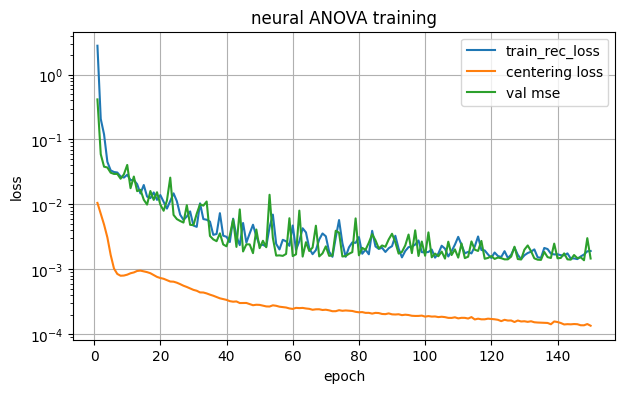

In [40]:
plt.figure(figsize=(7,4))
plt.semilogy(history['epoch'], history['train_rec_loss'], label='train_rec_loss')
plt.semilogy(history['epoch'], history['train_center_loss'], label='centering loss')
plt.semilogy(history['epoch'], history['val_mse'], label='val mse')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('neural ANOVA training')
plt.legend()
plt.grid(True)
plt.show()


In [41]:

@torch.no_grad()
def neural_anova_terms(model, X_np, batch_size):
    model.eval()
    outputs = []

    for start in range(0, len(X_np), batch_size):
        xb = torch.tensor(X_np[start:start+batch_size], dtype=torch.float32, device=device)
        terms = model.forward_terms(xb).cpu().numpy()
        outputs.append(terms)

    return np.vstack(outputs)


terms_val = neural_anova_terms(model, X_val.cpu().numpy(), batch_size=4096)

recon_val = terms_val.sum(axis=1)
neural_rmse = np.sqrt(np.mean((recon_val - y_val.cpu().numpy())**2))
neural_rel_rmse = neural_rmse / np.std(y_val.cpu().numpy())

print('net ANOVA rmse:', neural_rmse)
print('net ANOVA relative rmse:', neural_rel_rmse)
print('term means:')
for name, mu in zip(subset_names, terms_val.mean(axis=0)):
    print(f'{name}: {mu}')


net ANOVA rmse: 0.03824884
net ANOVA relative rmse: 0.17582263
term means:
0: 0.0016490768175572157
1: -0.005077950656414032
2: -0.001292525907047093
3: 0.11725359410047531
4: 0.1220555454492569
5: -0.013382543809711933
12: 0.0031576764304190874
13: 0.02024880051612854
14: 0.01558592077344656
15: 0.0184533279389143
23: 0.01534838043153286
24: -0.01781000941991806
25: 0.01970445178449154
34: 0.05331478640437126
35: 0.08109518885612488
45: 0.03031599335372448
123: 0.011137591674923897
124: -0.04179886728525162
125: 0.022785434499382973
134: -0.0171955693513155
135: 0.01721309870481491
145: 0.014508109539747238
234: 0.046782296150922775
235: 0.03117723949253559
245: 0.01239016279578209
345: 0.0011170170037075877
1234: 0.021151911467313766
1235: -0.001535815536044538
1245: 0.03066822700202465
1345: 0.018188485875725746
2345: 0.02991175837814808
12345: 0.031213918700814247


In [42]:

def sobol_from_terms(terms, subset_names):
    var_terms = terms.var(axis=0)
    total_var = terms.sum(axis=1).var()

    rows = []
    for name, v in zip(subset_names, var_terms):
        if name == '0':
            continue
        rows.append({
            'term': name,
            'variance': v,
            'sobol': v / total_var})

    return pd.DataFrame(rows), total_var


neural_sobol_df, neural_total_var = sobol_from_terms(terms_val, subset_names)
neural_sobol_df


,term,variance,sobol
0,1,6.456151e-05,0.001399
1,2,4.066865e-07,0.000009
2,3,1.823301e-03,0.039507
3,4,1.500538e-04,0.003251
4,5,7.512976e-05,0.001628
5,12,1.269753e-06,0.000028
6,13,6.611508e-05,0.001433
7,14,1.718739e-05,0.000372
8,15,5.249396e-05,0.001137
9,23,1.251650e-02,0.271206


In [43]:

def total_indices_from_sobol(sobol_df, d):
    result = {}
    for i in range(1, d + 1):
        total = 0.0
        for _, row in sobol_df.iterrows():
            if str(i) in row['term']:
                total += row['sobol']
        result['ST'+str(i)] = total
    return result


neural_total_indices = total_indices_from_sobol(neural_sobol_df, d)
neural_total_indices


{'ST1': 0.036200341677613324,
 'ST2': 0.2920323909020226,
 'ST3': 0.3739933889155509,
 'ST4': 0.041861934689222835,
 'ST5': 0.05039733520243317}

In [44]:

recon_val = terms_val.sum(axis=1)

anova_expec_reconstr = recon_val.mean()
term_means = terms_val.mean(axis=0)
anova_expec_terms = term_means.sum()

f0_mean = term_means[0]
true_expectation = y_val.cpu().numpy().mean()
anova_std = recon_val.std(ddof=1)
anova_standard_error = anova_std / np.sqrt(len(recon_val))

print('Eanova (reconstruction):', anova_expec_reconstr)
print('Eanova (sum of term means):', anova_expec_terms)
print('constant term f0:', f0_mean)
print('validation expectation:', true_expectation)
print('absolute error:', abs(anova_expec_reconstr - true_expectation))
print('standard error:', anova_standard_error)

Eanova (reconstruction): 0.6883354
Eanova (sum of term means): 0.6883347
constant term f0: 0.0016490768
validation expectation: 0.67922854
absolute error: 0.0091068745
standard error: 0.0006793502600637942


In [45]:

def multi_indices_total_degree(d, p):
    indices = []
    for alpha in itertools.product(range(p + 1), repeat=d):
        if sum(alpha) <= p:
            indices.append(alpha)
    return indices


def orthonormal_legendre_1d(x, max_degree):
    x = np.asarray(x)
    N = len(x)
    out = np.zeros((N, max_degree + 1), dtype=np.float64)

    for n in range(max_degree + 1):
        coeff = np.zeros(n + 1)
        coeff[-1] = 1.0
        Pn = legval(x, coeff)
        out[:, n] = math.sqrt(2 * n + 1) * Pn

    return out


def pce_design_matrix(X, multi_indices, max_degree):
    N, d = X.shape
    one_d = [orthonormal_legendre_1d(X[:, j], max_degree) for j in range(d)]

    Phi = np.ones((N, len(multi_indices)), dtype=np.float64)

    for k, alpha in enumerate(multi_indices):
        col = np.ones(N, dtype=np.float64)
        for j, deg in enumerate(alpha):
            col *= one_d[j][:, deg]
        Phi[:, k] = col

    return Phi


p_degree = 10
multi_idx = multi_indices_total_degree(d, p_degree)

print('PCE total degree:', p_degree)
print('Number of basis functions:', len(multi_idx))

Phi_train = pce_design_matrix(X_train.cpu().numpy().astype(np.float64), multi_idx, p_degree)
Phi_val = pce_design_matrix(X_val.cpu().numpy().astype(np.float64), multi_idx, p_degree)

coef, residuals, rank, svals = np.linalg.lstsq(Phi_train, y_train.cpu().numpy().astype(np.float64), rcond=None)

pce_pred_val = Phi_val @ coef

pce_rmse = np.sqrt(np.mean((pce_pred_val - y_val.cpu().numpy())**2))
pce_rel_rmse = pce_rmse / np.std(y_val.cpu().numpy())

print('PCE RMSE:', pce_rmse)
print('PCE relative RMSE:', pce_rel_rmse)
print('PCE rank:', rank)


PCE total degree: 10
Number of basis functions: 3003
PCE RMSE: 0.03774441788172554
PCE relative RMSE: 0.173503888714638
PCE rank: 1872


In [46]:

def pce_sobol_indices(coef, multi_indices, d):
    contrib = {}

    for c, alpha in zip(coef, multi_indices):
        support = tuple(i for i, deg in enumerate(alpha) if deg > 0)
        if len(support) == 0:
            continue
        name = "".join(str(i + 1) for i in support)
        contrib[name] = contrib.get(name, 0.0) + float(c**2)

    total_var = sum(contrib.values())

    rows = []
    for name in subset_names:
        if name == '0':
            continue
        v = contrib.get(name, 0.0)
        rows.append({'term': name,
            'variance': v,
            'sobol': v / total_var})

    return pd.DataFrame(rows), total_var


pce_sobol_df, pce_total_var = pce_sobol_indices(coef, multi_idx, d)
pce_sobol_df


,term,variance,sobol
0,1,0.010921,0.000913
1,2,0.003626,0.000303
2,3,2.577783,0.215404
3,4,0.037061,0.003097
4,5,0.025311,0.002115
5,12,0.034390,0.002874
6,13,0.438637,0.036653
7,14,0.051057,0.004266
8,15,0.039572,0.003307
9,23,0.252657,0.021112


In [47]:

pce_total_indices = total_indices_from_sobol(pce_sobol_df, d)
pce_total_indices


{'ST1': 0.26635822401499815,
 'ST2': 0.22636583044036976,
 'ST3': 0.9240679846799256,
 'ST4': 0.48673474885106016,
 'ST5': 0.4589244619861953}

In [48]:

total_compare = pd.DataFrame([
    {'method': 'neural_anova',
        'ST1': neural_total_indices['ST1'],
        'ST2': neural_total_indices['ST2'],
        'ST3': neural_total_indices['ST3'],
        'Var': neural_total_var},
    {'method': 'pce',
        'ST1': pce_total_indices['ST1'],
        'ST2': pce_total_indices['ST2'],
        'ST3': pce_total_indices['ST3'],
        'Var': pce_total_var}])

total_compare


,method,ST1,ST2,ST3,Var
0,neural_anova,0.036200,0.292032,0.373993,0.046151
1,pce,0.266358,0.226366,0.924068,11.967208
